# Implementación de Modelos

In [2]:
import sys
import platform

print('═' * 60)
print('SISTEMA')
print('═' * 60)
print(f'Python  : {sys.version.split()[0]}')
print(f'Sistema : {platform.system()} {platform.release()}')
print(f'Máquina : {platform.machine()}')

# ─── TensorFlow ─────────────────────────────────────────────────────
print('\n' + '═' * 60)
print('TENSORFLOW')
print('═' * 60)
try:
    import tensorflow as tf
    print(f' TensorFlow instalado: {tf.__version__}')
    print(f'   Keras version: {tf.keras.__version__}')
    print(f'   Built with CUDA: {tf.test.is_built_with_cuda()}')

    gpus = tf.config.list_physical_devices('GPU')
    print(f'\n   GPUs detectadas por TF: {len(gpus)}')
    for i, gpu in enumerate(gpus):
        print(f'      [{i}] {gpu.name}')

    # Test rápido de ejecución en GPU
    if len(gpus) > 0:
        try:
            with tf.device('/GPU:0'):
                a = tf.random.normal((1000, 1000))
                b = tf.random.normal((1000, 1000))
                c = tf.matmul(a, b)
            print('    Operación en GPU exitosa')
        except Exception as e:
            print(f'    Error al ejecutar en GPU: {e}')
    else:
        print('    No se detectó GPU — se entrenará en CPU (muy lento)')
except ImportError:
    print(' TensorFlow NO instalado')

# ─── PyTorch (informativo) ──────────────────────────────────────────
print('\n' + '═' * 60)
print('PYTORCH (informativo)')
print('═' * 60)
try:
    import torch
    print(f' PyTorch instalado: {torch.__version__}')
    print(f'   CUDA disponible: {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'   Dispositivo: {torch.cuda.get_device_name(0)}')
        print(f'   CUDA version: {torch.version.cuda}')
except ImportError:
    print(' PyTorch no instalado (no pasa nada, usaremos TensorFlow)')

# ─── Librerías de imagen ────────────────────────────────────────────
print('\n' + '═' * 60)
print('LIBRERÍAS DE PROCESAMIENTO DE IMAGEN')
print('═' * 60)
for lib_name in ['numpy', 'pandas', 'matplotlib', 'cv2', 'tifffile',
                  'PIL', 'skimage', 'sklearn', 'scipy']:
    try:
        mod = __import__(lib_name)
        ver = getattr(mod, '__version__', 'sin version')
        print(f'    {lib_name:12s} {ver}')
    except ImportError:
        print(f'    {lib_name:12s} NO instalado')

════════════════════════════════════════════════════════════
SISTEMA
════════════════════════════════════════════════════════════
Python  : 3.9.25
Sistema : Windows 10
Máquina : AMD64

════════════════════════════════════════════════════════════
TENSORFLOW
════════════════════════════════════════════════════════════
 TensorFlow instalado: 2.10.1
   Keras version: 2.10.0
   Built with CUDA: True

   GPUs detectadas por TF: 1
      [0] /physical_device:GPU:0
    Operación en GPU exitosa

════════════════════════════════════════════════════════════
PYTORCH (informativo)
════════════════════════════════════════════════════════════
 PyTorch no instalado (no pasa nada, usaremos TensorFlow)

════════════════════════════════════════════════════════════
LIBRERÍAS DE PROCESAMIENTO DE IMAGEN
════════════════════════════════════════════════════════════
    numpy        1.25.2
    pandas       2.3.3
    matplotlib   3.7.2
    cv2          4.13.0
    tifffile     2023.8.30
    PIL          10.0.0
  

In [3]:
# ═════════════════════════════════════════════════════════════════════
# IMPORTS Y CONFIGURACIÓN GLOBAL
# ═════════════════════════════════════════════════════════════════════
import os
import gc
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
import cv2

from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras import backend as K

# ─── Memory growth para no tomar toda la VRAM ────────────────────────
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# ─── Reproducibilidad ────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Estilo de plots ─────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print(' Imports y configuración listos')
print(f'   GPU memory growth activado')
print(f'   Seed: {SEED}')

Physical devices cannot be modified after being initialized
 Imports y configuración listos
   GPU memory growth activado
   Seed: 42


In [4]:
# ═════════════════════════════════════════════════════════════════════
# RUTAS E HIPERPARÁMETROS DEL EXPERIMENTO
# ═════════════════════════════════════════════════════════════════════

# ─── RUTAS ────────────────────────────────────────────────────────────
DATA_DIR  = Path(r'C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2\ProyectoUltrasound\ultrasound-nerve-segmentation')
TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR  = DATA_DIR / 'test'

EDA_CSV   = DATA_DIR / 'df_eda_processed.csv'
NORM_CSV  = DATA_DIR / 'norm_params.csv'

# Carpeta para resultados y pesos
RESULTS_DIR = DATA_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
WEIGHTS_DIR = RESULTS_DIR / 'weights'
WEIGHTS_DIR.mkdir(exist_ok=True)

# ─── HIPERPARÁMETROS ─────────────────────────────────────────────────
IMG_HEIGHT   = 256
IMG_WIDTH    = 256
IMG_CHANNELS = 1

BATCH_SIZE   = 8        # Bajar a 8 si aparece OOM en TU-Net
EPOCHS       = 50
LR           = 1e-4
N_RUNS       = 3         # Mínimo 3 runs según el entregable

# ─── Verificación ────────────────────────────────────────────────────
print('═' * 60)
print('CONFIGURACIÓN DEL EXPERIMENTO')
print('═' * 60)
print(f'Imagen          : {IMG_HEIGHT} x {IMG_WIDTH} x {IMG_CHANNELS}')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Epochs máximas  : {EPOCHS}')
print(f'Learning rate   : {LR}')
print(f'Runs por modelo : {N_RUNS}')
print(f'\nRutas:')
print(f'   DATA_DIR    : {DATA_DIR}')
print(f'   RESULTS_DIR : {RESULTS_DIR}')
print(f'   WEIGHTS_DIR : {WEIGHTS_DIR}')
print(f'\nArchivos del EDA:')
print(f'   EDA CSV existe  : {EDA_CSV.exists()}')
print(f'   NORM CSV existe : {NORM_CSV.exists()}')

════════════════════════════════════════════════════════════
CONFIGURACIÓN DEL EXPERIMENTO
════════════════════════════════════════════════════════════
Imagen          : 256 x 256 x 1
Batch size      : 8
Epochs máximas  : 50
Learning rate   : 0.0001
Runs por modelo : 3

Rutas:
   DATA_DIR    : C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2\ProyectoUltrasound\ultrasound-nerve-segmentation
   RESULTS_DIR : C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2\ProyectoUltrasound\ultrasound-nerve-segmentation\results
   WEIGHTS_DIR : C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2\ProyectoUltrasound\ultrasound-nerve-segmentation\results\weights

Archivos del EDA:
   EDA CSV existe  : True
   NORM CSV existe : True


In [6]:
# ═════════════════════════════════════════════════════════════════════
# CARGAR RESULTADOS DEL EDA Y PREPARAR SPLITS
# ═════════════════════════════════════════════════════════════════════

# ─── Cargar CSVs generados en el EDA ─────────────────────────────────
df = pd.read_csv(EDA_CSV)
norm_params = pd.read_csv(NORM_CSV)

NORM_MEAN = float(norm_params['mean'].iloc[0])
NORM_STD  = float(norm_params['std'].iloc[0])

# ─── Reconstruir rutas completas de las imágenes ─────────────────────
df['img_path']  = df['stem'].apply(lambda s: str(TRAIN_DIR / f'{s}.tif'))
df['mask_path'] = df['stem'].apply(lambda s: str(TRAIN_DIR / f'{s}_mask.tif'))

# ─── Separar por split ───────────────────────────────────────────────
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

# ─── Reporte ─────────────────────────────────────────────────────────
print('═' * 60)
print('DATOS CARGADOS')
print('═' * 60)
print(f'Total frames: {len(df):,}')
print(f'\nDistribución por split:')
summary = df.groupby('split').agg(
    n_frames=('stem', 'count'),
    n_patients=('patient_id', 'nunique'),
    nerve_rate=('nerve_present', 'mean')
).round(3)
print(summary.to_string())

print(f'\nParámetros de normalización (del EDA):')
print(f'   mean = {NORM_MEAN:.4f}')
print(f'   std  = {NORM_STD:.4f}')

# Verificación rápida: las rutas existen
sample_img  = Path(train_df['img_path'].iloc[0])
sample_mask = Path(train_df['mask_path'].iloc[0])
print(f'\nVerificación de rutas (primer archivo de train):')
print(f'   Imagen existe  : {sample_img.exists()}  ({sample_img.name})')
print(f'   Máscara existe : {sample_mask.exists()}  ({sample_mask.name})')

════════════════════════════════════════════════════════════
DATOS CARGADOS
════════════════════════════════════════════════════════════
Total frames: 5,635

Distribución por split:
       n_frames  n_patients  nerve_rate
split                                  
test        960           8       0.343
train      3836          32       0.439
val         839           7       0.371

Parámetros de normalización (del EDA):
   mean = 0.3877
   std  = 0.2181

Verificación de rutas (primer archivo de train):
   Imagen existe  : True  (3_1.tif)
   Máscara existe : True  (3_1_mask.tif)


In [7]:
# ═════════════════════════════════════════════════════════════════════
# PIPELINE DE DATOS (tf.data)
# Aplica on-the-fly: CLAHE + resize + z-score + augmentation
# ═════════════════════════════════════════════════════════════════════

# Instancia global de CLAHE (parámetros estándar para ultrasonido)
_CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def load_image_mask(img_path_bytes, mask_path_bytes):
    """
    Carga un par imagen-máscara .tif y aplica todo el preprocesamiento
    definido en el EDA: CLAHE → resize → z-score → binarización.
    """
    img_path  = img_path_bytes.decode('utf-8')
    mask_path = mask_path_bytes.decode('utf-8')

    # ─── 1. Leer .tif ────────────────────────────────────────────────
    img  = tifffile.imread(img_path)
    mask = tifffile.imread(mask_path)

    # ─── 2. Convertir a uint8 si es necesario ────────────────────────
    if img.dtype != np.uint8:
        img = (img / max(img.max(), 1) * 255).astype(np.uint8)

    # ─── 3. CLAHE para mejorar contraste local ───────────────────────
    img = _CLAHE.apply(img)

    # ─── 4. Resize (bilinear imagen, nearest máscara) ────────────────
    img  = cv2.resize(img,  (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)

    # ─── 5. Normalización z-score con parámetros del EDA ─────────────
    img = img.astype(np.float32) / 255.0
    img = (img - NORM_MEAN) / NORM_STD

    # ─── 6. Máscara binaria {0, 1} ───────────────────────────────────
    mask = (mask > 0).astype(np.float32)

    # Agregar dimensión de canal: (H, W) → (H, W, 1)
    img  = np.expand_dims(img,  axis=-1)
    mask = np.expand_dims(mask, axis=-1)
    return img, mask


def tf_load_image_mask(img_path, mask_path):
    """Wrapper para usar load_image_mask dentro de tf.data."""
    img, mask = tf.numpy_function(
        load_image_mask,
        inp=[img_path, mask_path],
        Tout=[tf.float32, tf.float32]
    )
    img.set_shape((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    mask.set_shape((IMG_HEIGHT, IMG_WIDTH, 1))
    return img, mask


def augment(img, mask):
    """
    Data augmentation solo para train: flips + ruido leve.
    - Flip horizontal: 50% probabilidad
    - Flip vertical: 20% (menos común en ultrasonido)
    - Ruido gaussiano: 50% con std=0.03 (simula speckle residual)
    """
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.8:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    if tf.random.uniform(()) > 0.5:
        noise = tf.random.normal(tf.shape(img), mean=0.0, stddev=0.03)
        img   = img + noise

    return img, mask


def build_dataset(dataframe, batch_size=BATCH_SIZE, training=False, shuffle=False):
    """
    Construye un tf.data.Dataset a partir de un DataFrame con columnas
    'img_path' y 'mask_path'.

    - training=True  → aplica data augmentation
    - shuffle=True   → mezcla los datos (solo para train)
    """
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe['img_path'].values,
        dataframe['mask_path'].values
    ))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(dataframe), 1000),
                        seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(tf_load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


print(' Pipeline de datos definido:')
print('   • load_image_mask    — carga + CLAHE + resize + normalización')
print('   • tf_load_image_mask — wrapper para tf.data')
print('   • augment            — flips + ruido (solo en train)')
print('   • build_dataset      — constructor principal del Dataset')

 Pipeline de datos definido:
   • load_image_mask    — carga + CLAHE + resize + normalización
   • tf_load_image_mask — wrapper para tf.data
   • augment            — flips + ruido (solo en train)
   • build_dataset      — constructor principal del Dataset


════════════════════════════════════════════════════════════
VERIFICACIÓN DEL PIPELINE
════════════════════════════════════════════════════════════

Batch de TRAIN (con augmentation):
   Imagen  shape: (4, 256, 256, 1)  dtype: <dtype: 'float32'>
   Máscara shape: (4, 256, 256, 1)  dtype: <dtype: 'float32'>
   Imagen  min/max: -1.839 / 2.888
   Imagen  mean/std: 0.241 / 1.227
   Máscara valores únicos: [0. 1.]

Batch de TEST (sin augmentation):
   Imagen  shape: (4, 256, 256, 1)  dtype: <dtype: 'float32'>
   Imagen  min/max: -1.778 / 2.808


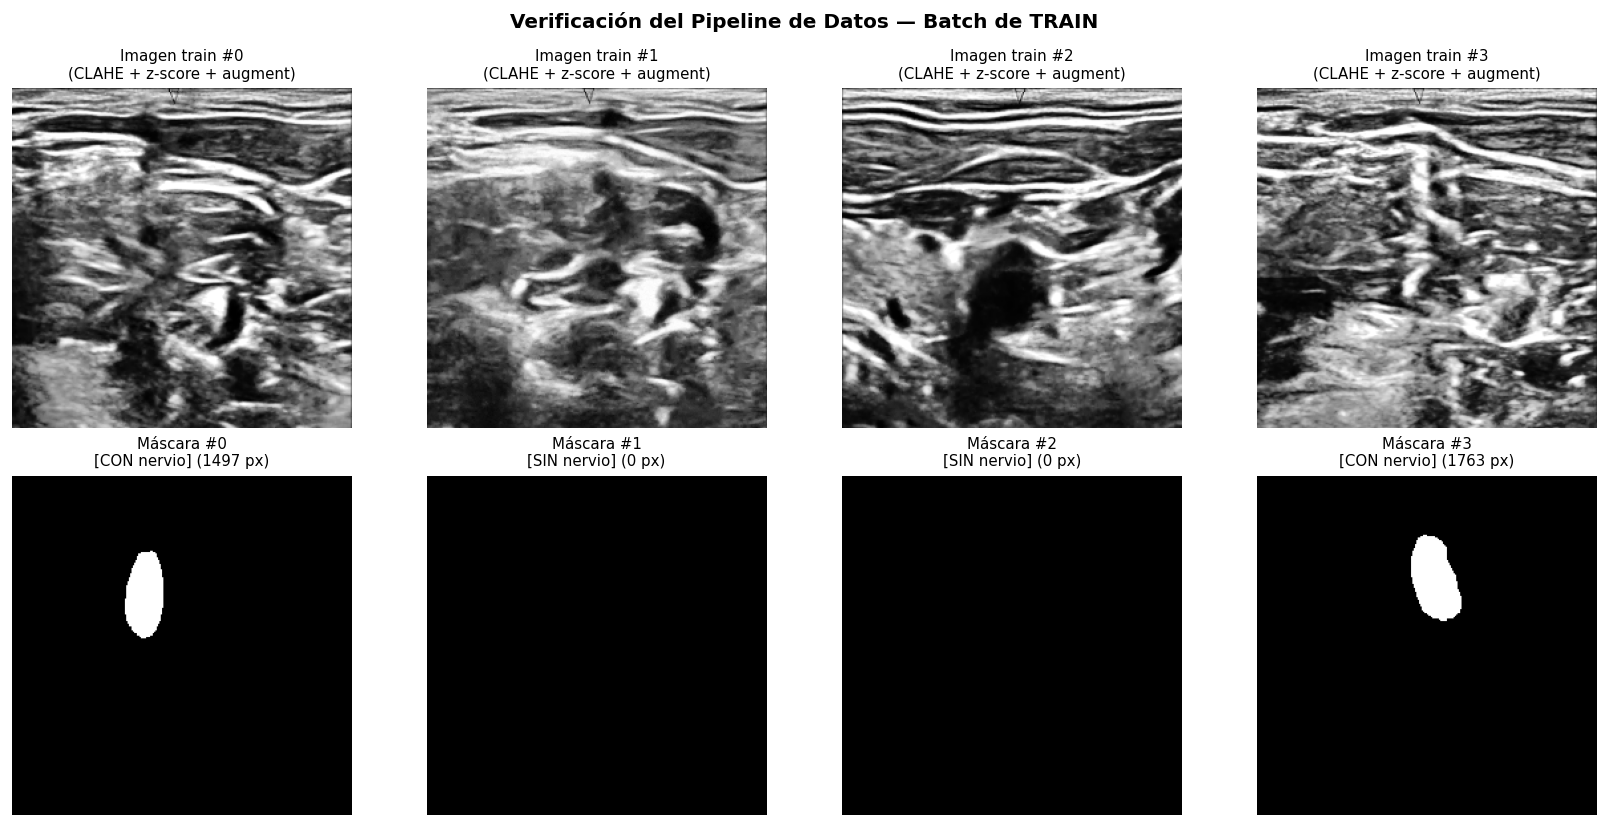


 Si las imágenes se ven con buen contraste y las máscaras se alinean → pipeline OK


In [8]:
# ═════════════════════════════════════════════════════════════════════
# VERIFICACIÓN DEL PIPELINE
# Confirmar que CLAHE + resize + normalización + augment funcionan bien
# ═════════════════════════════════════════════════════════════════════

# ─── Construir un dataset pequeño para inspeccionar ──────────────────
sample_train = build_dataset(train_df.head(16), batch_size=4, training=True, shuffle=False)
sample_test  = build_dataset(test_df.head(8),   batch_size=4, training=False, shuffle=False)

# ─── Cargar un batch de cada uno ─────────────────────────────────────
for imgs_tr, masks_tr in sample_train.take(1):
    break

for imgs_te, masks_te in sample_test.take(1):
    break

# ─── Reporte de shapes y rangos ──────────────────────────────────────
print('═' * 60)
print('VERIFICACIÓN DEL PIPELINE')
print('═' * 60)
print(f'\nBatch de TRAIN (con augmentation):')
print(f'   Imagen  shape: {imgs_tr.shape}  dtype: {imgs_tr.dtype}')
print(f'   Máscara shape: {masks_tr.shape}  dtype: {masks_tr.dtype}')
print(f'   Imagen  min/max: {imgs_tr.numpy().min():.3f} / {imgs_tr.numpy().max():.3f}')
print(f'   Imagen  mean/std: {imgs_tr.numpy().mean():.3f} / {imgs_tr.numpy().std():.3f}')
print(f'   Máscara valores únicos: {np.unique(masks_tr.numpy())}')

print(f'\nBatch de TEST (sin augmentation):')
print(f'   Imagen  shape: {imgs_te.shape}  dtype: {imgs_te.dtype}')
print(f'   Imagen  min/max: {imgs_te.numpy().min():.3f} / {imgs_te.numpy().max():.3f}')

# ─── Visualizar 4 muestras de train ──────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(imgs_tr[i, :, :, 0], cmap='gray')
    axes[0, i].set_title(f'Imagen train #{i}\n(CLAHE + z-score + augment)', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(masks_tr[i, :, :, 0], cmap='gray')
    mask_sum = int(masks_tr[i].numpy().sum())
    label = 'CON nervio' if mask_sum > 0 else 'SIN nervio'
    axes[1, i].set_title(f'Máscara #{i}\n[{label}] ({mask_sum} px)', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Verificación del Pipeline de Datos — Batch de TRAIN',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Si las imágenes se ven con buen contraste y las máscaras se alinean → pipeline OK')

In [9]:
# ═════════════════════════════════════════════════════════════════════
# MÉTRICAS Y FUNCIONES DE PÉRDIDA
# Dice coefficient (métrica principal de Kaggle)
# Dice Loss suavizado + BCE+Dice para manejar contradictorios
# ═════════════════════════════════════════════════════════════════════

SMOOTH = 1.0  # Factor de suavizado (robusto ante etiquetas contradictorias)


def dice_coef(y_true, y_pred, smooth=SMOOTH):
    """
    Dice Coefficient — métrica oficial de la competencia de Kaggle.

    Dice = (2 * |X ∩ Y|) / (|X| + |Y|)

    El smooth=1 evita división por cero cuando ambas máscaras son vacías
    y hace la métrica más robusta ante etiquetas ruidosas.
    """
    y_true_f = K.flatten(K.cast(y_true, 'float32'))
    y_pred_f = K.flatten(K.cast(y_pred, 'float32'))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    """Dice Loss = 1 - Dice. Función de pérdida diferenciable."""
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    """
    Combinación BCE + Dice Loss.

    - BCE estabiliza el entrenamiento en las primeras épocas
    - Dice optimiza directamente la métrica de evaluación
    - Combinación recomendada para datasets con ~60% de máscaras vacías
    """
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    return K.mean(bce) + dice_loss(y_true, y_pred)


def iou_metric(y_true, y_pred, threshold=0.5, smooth=SMOOTH):
    """
    IoU / Jaccard Index — métrica complementaria.

    IoU = |X ∩ Y| / |X ∪ Y|

    Es más estricta que Dice y útil para comparar modelos.
    """
    y_true = K.cast(y_true, 'float32')
    y_pred_bin = K.cast(y_pred > threshold, 'float32')
    intersection = K.sum(y_true * y_pred_bin)
    union = K.sum(y_true) + K.sum(y_pred_bin) - intersection
    return (intersection + smooth) / (union + smooth)


def pixel_accuracy(y_true, y_pred, threshold=0.5):
    """Proporción de píxeles correctamente clasificados."""
    y_true = K.cast(y_true, 'float32')
    y_pred_bin = K.cast(y_pred > threshold, 'float32')
    correct = K.cast(K.equal(y_true, y_pred_bin), 'float32')
    return K.mean(correct)


print(' Métricas y pérdidas definidas:')
print('   • dice_coef       — métrica principal (Kaggle)')
print('   • iou_metric      — métrica complementaria')
print('   • pixel_accuracy  — métrica secundaria')
print('   • dice_loss       — pérdida simple')
print('   • bce_dice_loss   — pérdida combinada (recomendada)')

 Métricas y pérdidas definidas:
   • dice_coef       — métrica principal (Kaggle)
   • iou_metric      — métrica complementaria
   • pixel_accuracy  — métrica secundaria
   • dice_loss       — pérdida simple
   • bce_dice_loss   — pérdida combinada (recomendada)


In [10]:
# ═════════════════════════════════════════════════════════════════════
# LOOP DE ENTRENAMIENTO GENÉRICO
# Entrena un modelo N veces con distintas semillas y reporta estadísticas
# Requisito del entregable: mínimo 3 runs + media ± std
# ═════════════════════════════════════════════════════════════════════

def train_model(model_builder, model_name,
                train_df, val_df, test_df,
                n_runs=N_RUNS, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                loss_fn=bce_dice_loss, verbose_fit=2):
    """
    Entrena un modelo N veces y retorna resultados agregados.

    Args:
        model_builder : función sin argumentos que retorna un modelo Keras SIN compilar
        model_name    : identificador string del modelo (usado en nombres de archivos)
        train/val/test: DataFrames con columnas 'img_path' y 'mask_path'
        n_runs        : número de ejecuciones con distintas semillas
        epochs        : épocas máximas por run (EarlyStopping puede cortar antes)
        loss_fn       : función de pérdida (default: bce_dice_loss)

    Returns:
        dict con:
            - 'model'       : nombre del modelo
            - 'runs'        : lista de dicts por run
            - 'dice_mean'   : media del Dice en test
            - 'dice_std'    : std del Dice en test
            - 'iou_mean'    : media del IoU en test
            - 'iou_std'     : std del IoU en test
            - 'time_mean'   : tiempo promedio de entrenamiento
            - 'n_params'    : número de parámetros del modelo
            - 'histories'   : lista de histories de Keras (para curvas de entrenamiento)
    """
    print('═' * 65)
    print(f'ENTRENANDO: {model_name}   ({n_runs} runs)')
    print('═' * 65)

    # ─── Datasets de validación y test (iguales para todos los runs) ─
    val_ds  = build_dataset(val_df,  batch_size=batch_size, training=False, shuffle=False)
    test_ds = build_dataset(test_df, batch_size=batch_size, training=False, shuffle=False)

    runs_results = []
    histories    = []
    n_params     = None

    for run_idx in range(n_runs):
        print(f'\n── Run {run_idx + 1}/{n_runs} ' + '─' * 50)

        # ─── Fijar semillas distintas por run para reproducibilidad ──
        run_seed = SEED + run_idx
        tf.random.set_seed(run_seed)
        np.random.seed(run_seed)
        random.seed(run_seed)

        # ─── Rebuild del dataset de train para shuffle distinto ──────
        train_ds = build_dataset(train_df, batch_size=batch_size,
                                 training=True, shuffle=True)

        # ─── Instanciar y compilar modelo nuevo ──────────────────────
        model = model_builder()
        model.compile(
            optimizer=optimizers.Adam(learning_rate=lr),
            loss=loss_fn,
            metrics=[dice_coef, iou_metric]
        )

        if n_params is None:
            n_params = model.count_params()
            print(f'   Parámetros del modelo: {n_params:,}')

        # ─── Callbacks ───────────────────────────────────────────────
        ckpt_path = WEIGHTS_DIR / f'{model_name}_run{run_idx+1}.weights.h5'
        cbs = [
            callbacks.ModelCheckpoint(
                filepath=str(ckpt_path),
                monitor='val_dice_coef',
                mode='max',
                save_best_only=True,
                save_weights_only=True,
                verbose=0
            ),
            callbacks.EarlyStopping(
                monitor='val_dice_coef',
                mode='max',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_dice_coef',
                mode='max',
                factor=0.5,
                patience=5,
                min_lr=1e-7,
                verbose=0
            )
        ]

        # ─── Entrenar ────────────────────────────────────────────────
        t0 = time.time()
        history = model.fit(
            train_ds,
            epochs=epochs,
            validation_data=val_ds,
            callbacks=cbs,
            verbose=verbose_fit
        )
        train_time = time.time() - t0

        # ─── Evaluar en test ─────────────────────────────────────────
        test_metrics = model.evaluate(test_ds, verbose=0)
        test_loss, test_dice, test_iou = test_metrics

        runs_results.append({
            'run'        : run_idx + 1,
            'test_dice'  : float(test_dice),
            'test_iou'   : float(test_iou),
            'test_loss'  : float(test_loss),
            'train_time' : train_time,
            'n_epochs'   : len(history.history['loss'])
        })
        histories.append(history.history)

        print(f'   → Test Dice : {test_dice:.4f}')
        print(f'   → Test IoU  : {test_iou:.4f}')
        print(f'   → Tiempo    : {train_time/60:.1f} min  ({len(history.history["loss"])} épocas)')

        # ─── Limpiar memoria ─────────────────────────────────────────
        del model
        K.clear_session()
        gc.collect()

    # ─── Resumen estadístico ─────────────────────────────────────────
    runs_df = pd.DataFrame(runs_results)
    summary = {
        'model'      : model_name,
        'runs'       : runs_results,
        'histories'  : histories,
        'n_params'   : n_params,
        'dice_mean'  : float(runs_df['test_dice'].mean()),
        'dice_std'   : float(runs_df['test_dice'].std()),
        'iou_mean'   : float(runs_df['test_iou'].mean()),
        'iou_std'    : float(runs_df['test_iou'].std()),
        'time_mean'  : float(runs_df['train_time'].mean()),
        'time_std'   : float(runs_df['train_time'].std()),
    }

    print('\n' + '═' * 65)
    print(f'RESULTADOS FINALES — {model_name}')
    print('═' * 65)
    print(f'Dice (test): {summary["dice_mean"]:.4f} ± {summary["dice_std"]:.4f}')
    print(f'IoU  (test): {summary["iou_mean"]:.4f} ± {summary["iou_std"]:.4f}')
    print(f'Parámetros : {summary["n_params"]:,}')
    print(f'Tiempo medio: {summary["time_mean"]/60:.1f} min por run')

    return summary


def plot_training_curves(results, metric='dice_coef'):
    """Visualiza las curvas de entrenamiento de todos los runs de un modelo."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for i, history in enumerate(results['histories']):
        axes[0].plot(history['loss'], alpha=0.5, label=f'Run {i+1} train')
        axes[0].plot(history['val_loss'], alpha=0.8, linestyle='--', label=f'Run {i+1} val')

        axes[1].plot(history[metric], alpha=0.5, label=f'Run {i+1} train')
        axes[1].plot(history[f'val_{metric}'], alpha=0.8, linestyle='--', label=f'Run {i+1} val')

    axes[0].set_title(f'Loss — {results["model"]}', fontweight='bold')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].set_title(f'{metric} — {results["model"]}', fontweight='bold')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel(metric)
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


print(' Funciones de entrenamiento definidas:')
print('   • train_model          — entrena N runs y retorna estadísticas')
print('   • plot_training_curves — visualiza curvas de entrenamiento')

 Funciones de entrenamiento definidas:
   • train_model          — entrena N runs y retorna estadísticas
   • plot_training_curves — visualiza curvas de entrenamiento


In [11]:
# ═════════════════════════════════════════════════════════════════════
# MODELO 1 — U-NET ORIGINAL (BASELINE)
# ─────────────────────────────────────────────────────────────────────
# Referencia: Ronneberger et al. (2015)
#   "U-Net: Convolutional Networks for Biomedical Image Segmentation"
#   MICCAI 2015 — arXiv:1505.04597
#
# Arquitectura: encoder-decoder con skip connections
#   - Encoder: 4 niveles de downsampling (Conv-Conv-Pool)
#   - Bottleneck
#   - Decoder: 4 niveles de upsampling (Upconv-Concat-Conv-Conv)
# ═════════════════════════════════════════════════════════════════════

def conv_block(x, filters, kernel_size=3, activation='relu', name=None):
    """Bloque estándar de U-Net: Conv → BN → Activation (x2)."""
    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_initializer='he_normal',
                      name=f'{name}_conv1' if name else None)(x)
    x = layers.BatchNormalization(name=f'{name}_bn1' if name else None)(x)
    x = layers.Activation(activation, name=f'{name}_act1' if name else None)(x)

    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_initializer='he_normal',
                      name=f'{name}_conv2' if name else None)(x)
    x = layers.BatchNormalization(name=f'{name}_bn2' if name else None)(x)
    x = layers.Activation(activation, name=f'{name}_act2' if name else None)(x)
    return x


def build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
               base_filters=32, depth=4):
    """
    U-Net original (Ronneberger et al. 2015).

    Args:
        input_shape  : shape de entrada (H, W, C)
        base_filters : filtros en el primer nivel (se duplican por nivel)
        depth        : profundidad del encoder (default: 4 niveles)

    Returns:
        modelo Keras sin compilar
    """
    inputs = layers.Input(shape=input_shape, name='input')

    # ─── ENCODER ─────────────────────────────────────────────────────
    skip_connections = []
    x = inputs
    for level in range(depth):
        filters = base_filters * (2 ** level)
        x = conv_block(x, filters, name=f'enc{level+1}')
        skip_connections.append(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f'pool{level+1}')(x)

    # ─── BOTTLENECK ──────────────────────────────────────────────────
    bottleneck_filters = base_filters * (2 ** depth)
    x = conv_block(x, bottleneck_filters, name='bottleneck')

    # ─── DECODER ─────────────────────────────────────────────────────
    for level in reversed(range(depth)):
        filters = base_filters * (2 ** level)
        x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2,
                                    padding='same', name=f'up{level+1}')(x)
        x = layers.Concatenate(name=f'concat{level+1}')([x, skip_connections[level]])
        x = conv_block(x, filters, name=f'dec{level+1}')

    # ─── OUTPUT ──────────────────────────────────────────────────────
    # dtype='float32' explícito para compatibilidad con mixed precision
    # (aunque no la estamos usando ahora, es buena práctica)
    outputs = layers.Conv2D(1, kernel_size=1, activation='sigmoid',
                            dtype='float32', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='U-Net')
    return model


# ─── Verificación de la arquitectura ─────────────────────────────────
model_test = build_unet()
print('═' * 60)
print('ARQUITECTURA U-NET (BASELINE)')
print('═' * 60)
print(f'Input shape  : {model_test.input_shape}')
print(f'Output shape : {model_test.output_shape}')
print(f'Parámetros   : {model_test.count_params():,}')
print(f'Profundidad  : 4 niveles')
print(f'Filtros base : 32 → 64 → 128 → 256 → 512 (bottleneck)')

# Resumen abreviado
model_test.summary(line_length=80)

# Limpiar
del model_test
K.clear_session()
gc.collect()

print('\n Arquitectura U-Net definida y verificada')

════════════════════════════════════════════════════════════
ARQUITECTURA U-NET (BASELINE)
════════════════════════════════════════════════════════════
Input shape  : (None, 256, 256, 1)
Output shape : (None, 256, 256, 1)
Parámetros   : 7,771,297
Profundidad  : 4 niveles
Filtros base : 32 → 64 → 128 → 256 → 512 (bottleneck)
Model: "U-Net"
________________________________________________________________________________
 Layer (type)             Output Shape      Param #  Connected to               
 input (InputLayer)       [(None, 256, 256  0        []                         
                          , 1)]                                                 
                                                                                
 enc1_conv1 (Conv2D)      (None, 256, 256,  320      ['input[0][0]']            
                           32)                                                  
                                                                                
 enc1_bn1 (

In [12]:
if 'all_results' not in globals():
    all_results = {}

In [14]:
# ═════════════════════════════════════════════════════════════════════
# ENTRENAMIENTO — MODELO 1: U-NET BASELINE
# ═════════════════════════════════════════════════════════════════════

# Diccionario global para guardar resultados de TODOS los modelos
# (se va llenando conforme entrenemos cada uno)
if 'all_results' not in globals():
    all_results = {}

# ─── Entrenar U-Net ──────────────────────────────────────────────────
results_unet = train_model(
    model_builder = build_unet,
    model_name    = 'UNet',
    train_df      = train_df,
    val_df        = val_df,
    test_df       = test_df,
    n_runs        = N_RUNS,
    epochs        = EPOCHS,
    batch_size    = BATCH_SIZE,
    lr            = LR,
    loss_fn       = bce_dice_loss
)

# Guardar en el diccionario global
all_results['UNet'] = results_unet

# ─── Guardar resultados a disco (por si acaso) ───────────────────────
import json
results_to_save = {
    'model'     : results_unet['model'],
    'runs'      : results_unet['runs'],
    'n_params'  : results_unet['n_params'],
    'dice_mean' : results_unet['dice_mean'],
    'dice_std'  : results_unet['dice_std'],
    'iou_mean'  : results_unet['iou_mean'],
    'iou_std'   : results_unet['iou_std'],
    'time_mean' : results_unet['time_mean'],
    'time_std'  : results_unet['time_std'],
}
with open(RESULTS_DIR / 'UNet_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print(f'\n Resultados guardados en: {RESULTS_DIR / "UNet_results.json"}')

═════════════════════════════════════════════════════════════════
ENTRENANDO: UNet   (3 runs)
═════════════════════════════════════════════════════════════════

── Run 1/3 ──────────────────────────────────────────────────
   Parámetros del modelo: 7,771,297
Epoch 1/50
480/480 - 186s - loss: 1.3038 - dice_coef: 0.0361 - iou_metric: 0.0646 - val_loss: 1.1970 - val_dice_coef: 0.0224 - val_iou_metric: 0.1236 - lr: 1.0000e-04 - 186s/epoch - 387ms/step
Epoch 2/50
480/480 - 220s - loss: 1.0619 - dice_coef: 0.1092 - iou_metric: 0.3370 - val_loss: 1.0661 - val_dice_coef: 0.1010 - val_iou_metric: 0.2088 - lr: 1.0000e-04 - 220s/epoch - 458ms/step
Epoch 3/50
480/480 - 230s - loss: 0.9269 - dice_coef: 0.1801 - iou_metric: 0.3852 - val_loss: 0.9646 - val_dice_coef: 0.1170 - val_iou_metric: 0.2069 - lr: 1.0000e-04 - 230s/epoch - 480ms/step
Epoch 4/50
480/480 - 203s - loss: 0.7928 - dice_coef: 0.2769 - iou_metric: 0.4167 - val_loss: 0.9055 - val_dice_coef: 0.1480 - val_iou_metric: 0.2658 - lr: 1.0000

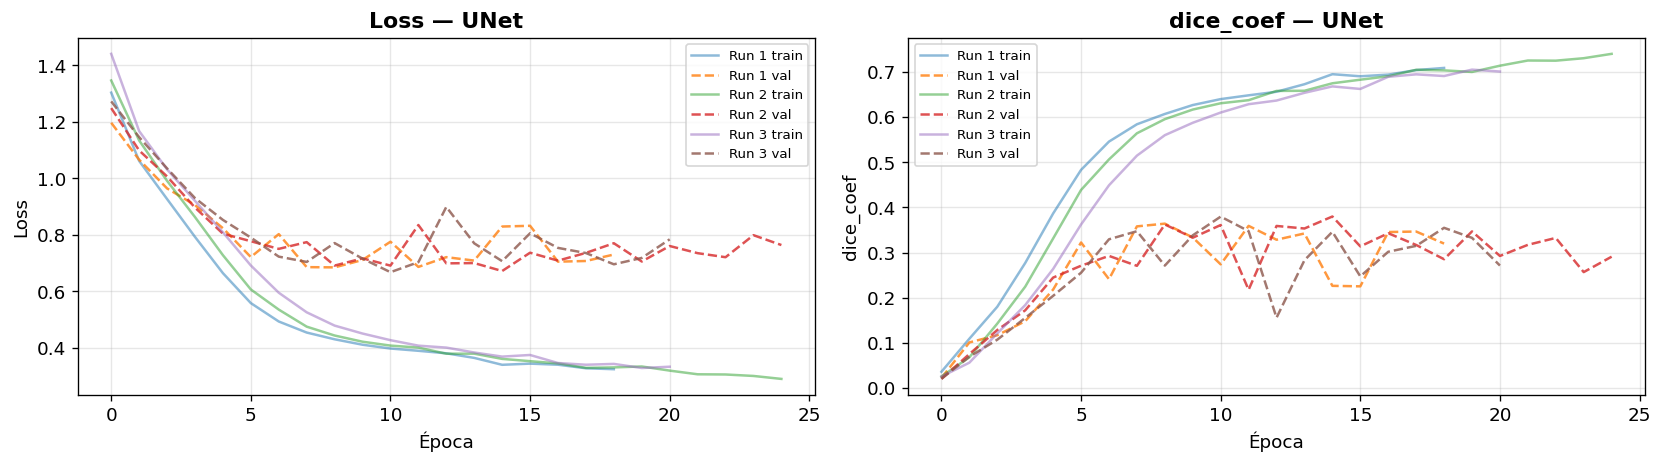


Resumen por run:
 run  test_dice  test_iou  test_loss  train_time  n_epochs
   1     0.3295    0.2425     0.7328   2922.4402        19
   2     0.2947    0.2497     0.7649   3373.3054        25
   3     0.3299    0.2517     0.7219   2886.5497        21

═══ Agregado ═══
Dice: 0.3180 ± 0.0202
IoU : 0.2480 ± 0.0048


In [15]:
# ─── Visualización de curvas de entrenamiento — U-Net ────────────────
plot_training_curves(results_unet, metric='dice_coef')

# Resumen detallado por run
print('\nResumen por run:')
print(pd.DataFrame(results_unet['runs']).round(4).to_string(index=False))

print(f'\n═══ Agregado ═══')
print(f'Dice: {results_unet["dice_mean"]:.4f} ± {results_unet["dice_std"]:.4f}')
print(f'IoU : {results_unet["iou_mean"]:.4f} ± {results_unet["iou_std"]:.4f}')

In [16]:
# ─── Ajuste de runs para los modelos restantes ───────────────────────
# U-Net ya se entrenó con 3 runs. Los modelos 2-5 usarán 2 runs para
# ahorrar tiempo total de experimentación.
N_RUNS_REMAINING = 3
print(f'  N_RUNS ajustado a {N_RUNS_REMAINING} para los modelos restantes')
print(f'    (U-Net mantiene sus 3 runs originales)')

  N_RUNS ajustado a 3 para los modelos restantes
    (U-Net mantiene sus 3 runs originales)


In [17]:
# ═════════════════════════════════════════════════════════════════════
# PIPELINE MEJORADO PARA MODELOS 2-5
# Augmentation más agresivo + dropout en las arquitecturas
# ═════════════════════════════════════════════════════════════════════

def augment_strong(img, mask):
    """
    Data augmentation mejorado para reducir overfitting.
    - Flips (igual que antes)
    - Rotaciones pequeñas ±15°
    - Brillo aleatorio ±20%
    - Contraste aleatorio ±20%
    - Ruido gaussiano leve
    """
    # Horizontal flip
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    # Vertical flip (menos probable)
    if tf.random.uniform(()) > 0.8:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    # Rotación aleatoria (múltiplos de 90° — conserva alineación perfecta)
    k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
    img  = tf.image.rot90(img,  k=k)
    mask = tf.image.rot90(mask, k=k)

    # Brillo aleatorio (solo sobre la imagen, no la máscara)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.random_brightness(img, max_delta=0.2)

    # Contraste aleatorio
    if tf.random.uniform(()) > 0.5:
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)

    # Ruido gaussiano
    if tf.random.uniform(()) > 0.5:
        noise = tf.random.normal(tf.shape(img), mean=0.0, stddev=0.03)
        img   = img + noise

    return img, mask


def build_dataset_v2(dataframe, batch_size=BATCH_SIZE, training=False, shuffle=False):
    """
    Versión 2 del builder de datasets — usa augment_strong en training.
    """
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe['img_path'].values,
        dataframe['mask_path'].values
    ))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(dataframe), 1000),
                        seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(tf_load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(augment_strong, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


print(' Pipeline mejorado definido:')
print('   • augment_strong   — flips + rotaciones + brillo + contraste + ruido')
print('   • build_dataset_v2 — usa augment_strong')
print('\n Los modelos 2-5 usarán este pipeline mejorado.')
print('   U-Net (modelo 1) queda con el pipeline original como baseline.')

 Pipeline mejorado definido:
   • augment_strong   — flips + rotaciones + brillo + contraste + ruido
   • build_dataset_v2 — usa augment_strong

 Los modelos 2-5 usarán este pipeline mejorado.
   U-Net (modelo 1) queda con el pipeline original como baseline.


In [18]:
# ─── Versión v2 de train_model: usa build_dataset_v2 ──────────────────
def train_model_v2(model_builder, model_name,
                   train_df, val_df, test_df,
                   n_runs=N_RUNS_REMAINING, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                   loss_fn=bce_dice_loss, verbose_fit=2):
    """Idéntica a train_model pero usa build_dataset_v2 (augment_strong)."""
    print('═' * 65)
    print(f'ENTRENANDO: {model_name}   ({n_runs} runs — pipeline mejorado)')
    print('═' * 65)

    val_ds  = build_dataset_v2(val_df,  batch_size=batch_size, training=False, shuffle=False)
    test_ds = build_dataset_v2(test_df, batch_size=batch_size, training=False, shuffle=False)

    runs_results = []
    histories    = []
    n_params     = None

    for run_idx in range(n_runs):
        print(f'\n── Run {run_idx + 1}/{n_runs} ' + '─' * 50)

        run_seed = SEED + run_idx
        tf.random.set_seed(run_seed)
        np.random.seed(run_seed)
        random.seed(run_seed)

        train_ds = build_dataset_v2(train_df, batch_size=batch_size,
                                     training=True, shuffle=True)

        model = model_builder()
        model.compile(
            optimizer=optimizers.Adam(learning_rate=lr),
            loss=loss_fn,
            metrics=[dice_coef, iou_metric]
        )

        if n_params is None:
            n_params = model.count_params()
            print(f'   Parámetros del modelo: {n_params:,}')

        ckpt_path = WEIGHTS_DIR / f'{model_name}_run{run_idx+1}.weights.h5'
        cbs = [
            callbacks.ModelCheckpoint(
                filepath=str(ckpt_path),
                monitor='val_dice_coef',
                mode='max',
                save_best_only=True,
                save_weights_only=True,
                verbose=0
            ),
            callbacks.EarlyStopping(
                monitor='val_dice_coef',
                mode='max',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_dice_coef',
                mode='max',
                factor=0.5,
                patience=5,
                min_lr=1e-7,
                verbose=0
            )
        ]

        t0 = time.time()
        history = model.fit(
            train_ds,
            epochs=epochs,
            validation_data=val_ds,
            callbacks=cbs,
            verbose=verbose_fit
        )
        train_time = time.time() - t0

        test_metrics = model.evaluate(test_ds, verbose=0)
        test_loss, test_dice, test_iou = test_metrics

        runs_results.append({
            'run'        : run_idx + 1,
            'test_dice'  : float(test_dice),
            'test_iou'   : float(test_iou),
            'test_loss'  : float(test_loss),
            'train_time' : train_time,
            'n_epochs'   : len(history.history['loss'])
        })
        histories.append(history.history)

        print(f'   → Test Dice : {test_dice:.4f}')
        print(f'   → Test IoU  : {test_iou:.4f}')
        print(f'   → Tiempo    : {train_time/60:.1f} min  ({len(history.history["loss"])} épocas)')

        del model
        K.clear_session()
        gc.collect()

    runs_df = pd.DataFrame(runs_results)
    summary = {
        'model'      : model_name,
        'runs'       : runs_results,
        'histories'  : histories,
        'n_params'   : n_params,
        'dice_mean'  : float(runs_df['test_dice'].mean()),
        'dice_std'   : float(runs_df['test_dice'].std()) if len(runs_df) > 1 else 0.0,
        'iou_mean'   : float(runs_df['test_iou'].mean()),
        'iou_std'    : float(runs_df['test_iou'].std()) if len(runs_df) > 1 else 0.0,
        'time_mean'  : float(runs_df['train_time'].mean()),
        'time_std'   : float(runs_df['train_time'].std()) if len(runs_df) > 1 else 0.0,
    }

    print('\n' + '═' * 65)
    print(f'RESULTADOS FINALES — {model_name}')
    print('═' * 65)
    print(f'Dice (test): {summary["dice_mean"]:.4f} ± {summary["dice_std"]:.4f}')
    print(f'IoU  (test): {summary["iou_mean"]:.4f} ± {summary["iou_std"]:.4f}')
    print(f'Parámetros : {summary["n_params"]:,}')
    print(f'Tiempo medio: {summary["time_mean"]/60:.1f} min por run')

    return summary


print(' train_model_v2 definida (usa pipeline mejorado para modelos 2-5)')

 train_model_v2 definida (usa pipeline mejorado para modelos 2-5)


In [19]:
# ═════════════════════════════════════════════════════════════════════
# MODELO 2 — ATTENTION U-NET
# ─────────────────────────────────────────────────────────────────────
# Referencia: Oktay et al. (2018)
#   "Attention U-Net: Learning Where to Look for the Pancreas"
#   MIDL 2018 — arXiv:1804.03999
#
# Arquitectura: U-Net + Attention Gates en los skip connections.
# Los AG aprenden a suprimir activaciones irrelevantes y enfocar
# en las regiones que contienen el objetivo — ataca directamente
# el problema de falsos positivos que observamos en U-Net baseline.
#
# Mejora adicional: dropout 0.2 en decoder para reducir overfitting
# ═════════════════════════════════════════════════════════════════════

def attention_gate(g, x, inter_channels, name):
    """
    Attention Gate (AG).
    
    Args:
        g : señal de gating (viene del decoder, de nivel más profundo)
        x : feature map del encoder (skip connection)
        inter_channels : canales intermedios del gate

    Returns:
        x * alpha — donde alpha es el mapa de atención aprendido
    """
    # Proyección lineal de g y x a espacio común
    g1 = layers.Conv2D(inter_channels, 1, padding='same', name=f'{name}_Wg')(g)
    g1 = layers.BatchNormalization(name=f'{name}_Wg_bn')(g1)

    x1 = layers.Conv2D(inter_channels, 1, padding='same', name=f'{name}_Wx')(x)
    x1 = layers.BatchNormalization(name=f'{name}_Wx_bn')(x1)

    # Suma + ReLU
    psi = layers.Add(name=f'{name}_add')([g1, x1])
    psi = layers.Activation('relu', name=f'{name}_relu')(psi)

    # Mapa de atención: 1 canal con sigmoid → valores en [0,1]
    psi = layers.Conv2D(1, 1, padding='same', name=f'{name}_psi')(psi)
    psi = layers.BatchNormalization(name=f'{name}_psi_bn')(psi)
    psi = layers.Activation('sigmoid', name=f'{name}_alpha')(psi)

    # Aplicar atención al skip connection
    return layers.Multiply(name=f'{name}_gated')([x, psi])


def conv_block_v2(x, filters, kernel_size=3, activation='relu',
                  dropout_rate=0.0, name=None):
    """Bloque Conv-BN-Act con dropout opcional."""
    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_initializer='he_normal',
                      name=f'{name}_conv1' if name else None)(x)
    x = layers.BatchNormalization(name=f'{name}_bn1' if name else None)(x)
    x = layers.Activation(activation, name=f'{name}_act1' if name else None)(x)

    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_initializer='he_normal',
                      name=f'{name}_conv2' if name else None)(x)
    x = layers.BatchNormalization(name=f'{name}_bn2' if name else None)(x)
    x = layers.Activation(activation, name=f'{name}_act2' if name else None)(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate, name=f'{name}_drop' if name else None)(x)
    return x


def build_attention_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
                         base_filters=32, depth=4, dropout_rate=0.2):
    """
    Attention U-Net (Oktay et al. 2018).

    Args:
        input_shape  : shape de entrada
        base_filters : filtros base (se duplican por nivel)
        depth        : profundidad del encoder
        dropout_rate : dropout en bottleneck y decoder

    Returns:
        modelo Keras sin compilar
    """
    inputs = layers.Input(shape=input_shape, name='input')

    # ─── ENCODER ─────────────────────────────────────────────────────
    skip_connections = []
    x = inputs
    for level in range(depth):
        filters = base_filters * (2 ** level)
        x = conv_block_v2(x, filters, name=f'enc{level+1}')
        skip_connections.append(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f'pool{level+1}')(x)

    # ─── BOTTLENECK (con dropout) ────────────────────────────────────
    bottleneck_filters = base_filters * (2 ** depth)
    x = conv_block_v2(x, bottleneck_filters,
                      dropout_rate=dropout_rate, name='bottleneck')

    # ─── DECODER con ATTENTION GATES ─────────────────────────────────
    for level in reversed(range(depth)):
        filters = base_filters * (2 ** level)

        # Upsample
        x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2,
                                    padding='same', name=f'up{level+1}')(x)

        # Attention Gate sobre el skip connection
        skip = skip_connections[level]
        gated_skip = attention_gate(g=x, x=skip,
                                     inter_channels=filters // 2,
                                     name=f'ag{level+1}')

        # Concat y conv block con dropout
        x = layers.Concatenate(name=f'concat{level+1}')([x, gated_skip])
        x = conv_block_v2(x, filters,
                          dropout_rate=dropout_rate,
                          name=f'dec{level+1}')

    # ─── OUTPUT ──────────────────────────────────────────────────────
    outputs = layers.Conv2D(1, kernel_size=1, activation='sigmoid',
                            dtype='float32', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='Attention-U-Net')
    return model


# ─── Verificación de la arquitectura ─────────────────────────────────
model_test = build_attention_unet()
print('═' * 60)
print('ARQUITECTURA ATTENTION U-NET')
print('═' * 60)
print(f'Input shape  : {model_test.input_shape}')
print(f'Output shape : {model_test.output_shape}')
print(f'Parámetros   : {model_test.count_params():,}')
print(f'Dropout rate : 0.2 (bottleneck + decoder)')
print(f'Attention Gates: 4 (uno por cada skip connection)')

# Limpiar
del model_test
K.clear_session()
gc.collect()

print('\n Arquitectura Attention U-Net definida')

════════════════════════════════════════════════════════════
ARQUITECTURA ATTENTION U-NET
════════════════════════════════════════════════════════════
Input shape  : (None, 256, 256, 1)
Output shape : (None, 256, 256, 1)
Parámetros   : 7,860,997
Dropout rate : 0.2 (bottleneck + decoder)
Attention Gates: 4 (uno por cada skip connection)

 Arquitectura Attention U-Net definida


In [ ]:
# ═════════════════════════════════════════════════════════════════════
# ENTRENAMIENTO — MODELO 2: ATTENTION U-NET
# Pipeline mejorado (augment_strong + dropout)
# ═════════════════════════════════════════════════════════════════════

results_attunet = train_model_v2(
    model_builder = build_attention_unet,
    model_name    = 'AttentionUNet',
    train_df      = train_df,
    val_df        = val_df,
    test_df       = test_df,
    n_runs        = N_RUNS_REMAINING,
    epochs        = EPOCHS,
    batch_size    = BATCH_SIZE,
    lr            = LR,
    loss_fn       = bce_dice_loss
)

# Guardar en el diccionario global
all_results['AttentionUNet'] = results_attunet

# ─── Guardar resultados a disco ──────────────────────────────────────
import json
results_to_save = {
    'model'     : results_attunet['model'],
    'runs'      : results_attunet['runs'],
    'n_params'  : results_attunet['n_params'],
    'dice_mean' : results_attunet['dice_mean'],
    'dice_std'  : results_attunet['dice_std'],
    'iou_mean'  : results_attunet['iou_mean'],
    'iou_std'   : results_attunet['iou_std'],
    'time_mean' : results_attunet['time_mean'],
    'time_std'  : results_attunet['time_std'],
}
with open(RESULTS_DIR / 'AttentionUNet_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print(f'\n Resultados guardados en: {RESULTS_DIR / "AttentionUNet_results.json"}')

═════════════════════════════════════════════════════════════════
ENTRENANDO: AttentionUNet   (3 runs — pipeline mejorado)
═════════════════════════════════════════════════════════════════

── Run 1/3 ──────────────────────────────────────────────────
   Parámetros del modelo: 7,860,997
Epoch 1/50
480/480 - 162s - loss: 1.1294 - dice_coef: 0.0738 - iou_metric: 0.1374 - val_loss: 1.0434 - val_dice_coef: 0.0642 - val_iou_metric: 0.1292 - lr: 1.0000e-04 - 162s/epoch - 338ms/step
Epoch 2/50
480/480 - 158s - loss: 0.9066 - dice_coef: 0.1886 - iou_metric: 0.3116 - val_loss: 0.9128 - val_dice_coef: 0.1758 - val_iou_metric: 0.2108 - lr: 1.0000e-04 - 158s/epoch - 330ms/step
Epoch 3/50
480/480 - 160s - loss: 0.7677 - dice_coef: 0.2969 - iou_metric: 0.3585 - val_loss: 0.8200 - val_dice_coef: 0.2417 - val_iou_metric: 0.2287 - lr: 1.0000e-04 - 160s/epoch - 333ms/step
Epoch 4/50
480/480 - 156s - loss: 0.6522 - dice_coef: 0.3997 - iou_metric: 0.3920 - val_loss: 0.7680 - val_dice_coef: 0.2940 - val_io

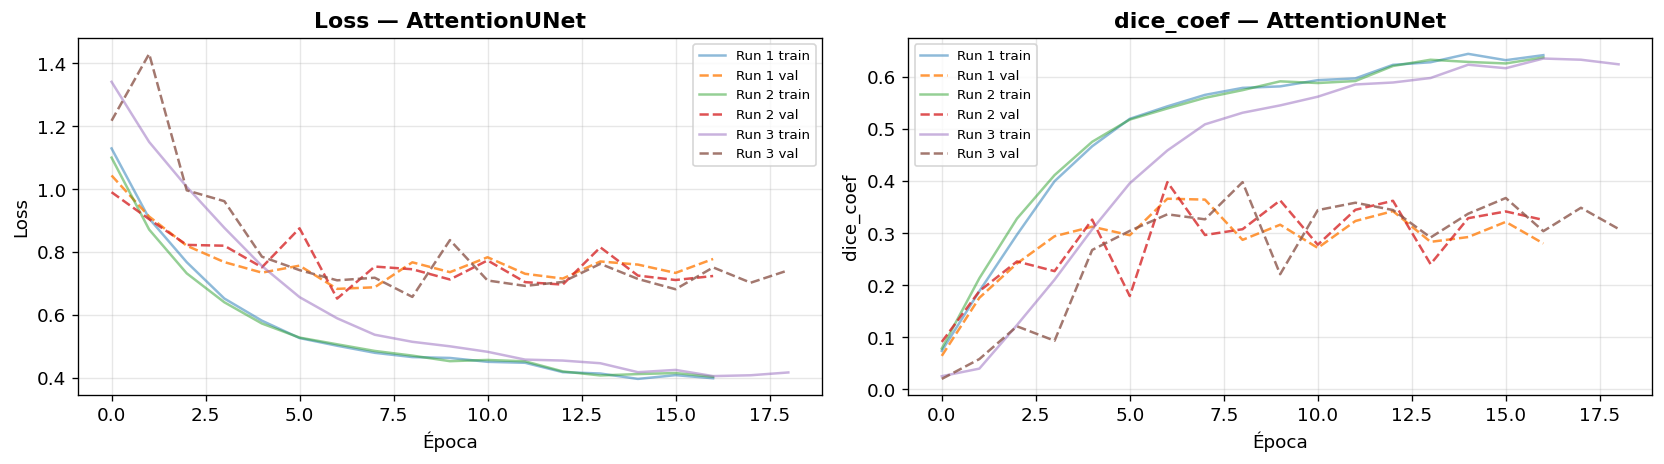


Resumen por run:
 run  test_dice  test_iou  test_loss  train_time  n_epochs
   1     0.3012    0.2152     0.7544   2649.8932        17
   2     0.3076    0.2099     0.7508   2612.1823        17
   3     0.3489    0.2539     0.7068   3256.1623        19

═══ Comparación con U-Net ═══
U-Net          : Dice = 0.3180 ± 0.0202
Attention U-Net: Dice = 0.3192 ± 0.0259

Mejora: +0.0012 (+0.4%)


In [21]:
# ─── Curvas y resumen ────────────────────────────────────────────────
plot_training_curves(results_attunet, metric='dice_coef')

print('\nResumen por run:')
print(pd.DataFrame(results_attunet['runs']).round(4).to_string(index=False))

print(f'\n═══ Comparación con U-Net ═══')
print(f'U-Net          : Dice = {all_results["UNet"]["dice_mean"]:.4f} ± {all_results["UNet"]["dice_std"]:.4f}')
print(f'Attention U-Net: Dice = {all_results["AttentionUNet"]["dice_mean"]:.4f} ± {all_results["AttentionUNet"]["dice_std"]:.4f}')

improvement = all_results["AttentionUNet"]["dice_mean"] - all_results["UNet"]["dice_mean"]
print(f'\nMejora: {improvement:+.4f} ({100*improvement/all_results["UNet"]["dice_mean"]:+.1f}%)')

In [22]:
# ═════════════════════════════════════════════════════════════════════
# MODELO 3 — RESU-NET (RESIDUAL U-NET)
# ─────────────────────────────────────────────────────────────────────
# Referencia: Zhang et al. (2018)
#   "Road Extraction by Deep Residual U-Net"
#   IEEE Geoscience and Remote Sensing Letters — arXiv:1711.10684
#
# Motivación: Los bloques residuales (ResNet-style) facilitan el
# entrenamiento de redes profundas mediante skip connections internas,
# evitando el vanishing gradient y permitiendo aprender mejor features
# multi-escala — útil para target pequeño y ruidoso como este.
#
# Con dropout 0.2 en el bottleneck y decoder para reducir overfitting
# ═════════════════════════════════════════════════════════════════════

def residual_block(x, filters, kernel_size=3, name=None):
    """
    Bloque residual estilo ResNet.
    
    Estructura:
        x ──► [Conv-BN-Act-Conv-BN] ──► (+) ──► Act ──► output
        └───────────► [1x1 Conv (shortcut)] ─► ┘
    
    El shortcut 1x1 ajusta el número de canales cuando difiere.
    """
    # Guardar shortcut
    shortcut = x
    input_channels = x.shape[-1]

    # Primera convolución
    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_initializer='he_normal',
                      name=f'{name}_conv1' if name else None)(x)
    x = layers.BatchNormalization(name=f'{name}_bn1' if name else None)(x)
    x = layers.Activation('relu', name=f'{name}_act1' if name else None)(x)

    # Segunda convolución
    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_initializer='he_normal',
                      name=f'{name}_conv2' if name else None)(x)
    x = layers.BatchNormalization(name=f'{name}_bn2' if name else None)(x)

    # Ajustar shortcut si hay cambio de canales
    if input_channels != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same',
                                  kernel_initializer='he_normal',
                                  name=f'{name}_shortcut' if name else None)(shortcut)
        shortcut = layers.BatchNormalization(
            name=f'{name}_shortcut_bn' if name else None)(shortcut)

    # Suma residual + activación final
    x = layers.Add(name=f'{name}_add' if name else None)([x, shortcut])
    x = layers.Activation('relu', name=f'{name}_act2' if name else None)(x)
    return x


def build_resunet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
                  base_filters=32, depth=4, dropout_rate=0.2):
    """
    ResU-Net — U-Net con bloques residuales en encoder, bottleneck y decoder.
    """
    inputs = layers.Input(shape=input_shape, name='input')

    # ─── ENCODER (bloques residuales) ────────────────────────────────
    skip_connections = []
    x = inputs
    for level in range(depth):
        filters = base_filters * (2 ** level)
        x = residual_block(x, filters, name=f'enc{level+1}')
        skip_connections.append(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f'pool{level+1}')(x)

    # ─── BOTTLENECK residual + dropout ───────────────────────────────
    bottleneck_filters = base_filters * (2 ** depth)
    x = residual_block(x, bottleneck_filters, name='bottleneck')
    x = layers.Dropout(dropout_rate, name='bottleneck_drop')(x)

    # ─── DECODER (upconv + residual block + dropout) ─────────────────
    for level in reversed(range(depth)):
        filters = base_filters * (2 ** level)

        x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2,
                                    padding='same', name=f'up{level+1}')(x)
        x = layers.Concatenate(name=f'concat{level+1}')([x, skip_connections[level]])
        x = residual_block(x, filters, name=f'dec{level+1}')
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate, name=f'dec{level+1}_drop')(x)

    # ─── OUTPUT ──────────────────────────────────────────────────────
    outputs = layers.Conv2D(1, kernel_size=1, activation='sigmoid',
                            dtype='float32', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='ResU-Net')
    return model


# ─── Verificación de la arquitectura ─────────────────────────────────
model_test = build_resunet()
print('═' * 60)
print('ARQUITECTURA RESU-NET')
print('═' * 60)
print(f'Input shape   : {model_test.input_shape}')
print(f'Output shape  : {model_test.output_shape}')
print(f'Parámetros    : {model_test.count_params():,}')
print(f'Dropout rate  : 0.2 (bottleneck + decoder)')
print(f'Residual blocks: {2 * 4 + 1} (encoder x4 + bottleneck + decoder x4)')

del model_test
K.clear_session()
gc.collect()

print('\n Arquitectura ResU-Net definida')

════════════════════════════════════════════════════════════
ARQUITECTURA RESU-NET
════════════════════════════════════════════════════════════
Input shape   : (None, 256, 256, 1)
Output shape  : (None, 256, 256, 1)
Parámetros    : 8,126,849
Dropout rate  : 0.2 (bottleneck + decoder)
Residual blocks: 9 (encoder x4 + bottleneck + decoder x4)

 Arquitectura ResU-Net definida


In [23]:
# ═════════════════════════════════════════════════════════════════════
# ENTRENAMIENTO — MODELO 3: RESU-NET
# Pipeline mejorado (augment_strong + dropout en bloques residuales)
# ═════════════════════════════════════════════════════════════════════

results_resunet = train_model_v2(
    model_builder = build_resunet,
    model_name    = 'ResUNet',
    train_df      = train_df,
    val_df        = val_df,
    test_df       = test_df,
    n_runs        = N_RUNS_REMAINING,
    epochs        = EPOCHS,
    batch_size    = BATCH_SIZE,
    lr            = LR,
    loss_fn       = bce_dice_loss
)

# Guardar en el diccionario global
all_results['ResUNet'] = results_resunet

# ─── Guardar resultados a disco ──────────────────────────────────────
import json
results_to_save = {
    'model'     : results_resunet['model'],
    'runs'      : results_resunet['runs'],
    'n_params'  : results_resunet['n_params'],
    'dice_mean' : results_resunet['dice_mean'],
    'dice_std'  : results_resunet['dice_std'],
    'iou_mean'  : results_resunet['iou_mean'],
    'iou_std'   : results_resunet['iou_std'],
    'time_mean' : results_resunet['time_mean'],
    'time_std'  : results_resunet['time_std'],
}
with open(RESULTS_DIR / 'ResUNet_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print(f'\n Resultados guardados en: {RESULTS_DIR / "ResUNet_results.json"}')

═════════════════════════════════════════════════════════════════
ENTRENANDO: ResUNet   (3 runs — pipeline mejorado)
═════════════════════════════════════════════════════════════════

── Run 1/3 ──────────────────────────────────────────────────
   Parámetros del modelo: 8,126,849
Epoch 1/50
480/480 - 163s - loss: 0.9723 - dice_coef: 0.1624 - iou_metric: 0.1899 - val_loss: 0.8433 - val_dice_coef: 0.2199 - val_iou_metric: 0.2013 - lr: 1.0000e-04 - 163s/epoch - 340ms/step
Epoch 2/50
480/480 - 160s - loss: 0.6884 - dice_coef: 0.3683 - iou_metric: 0.3334 - val_loss: 0.7958 - val_dice_coef: 0.2563 - val_iou_metric: 0.1986 - lr: 1.0000e-04 - 160s/epoch - 333ms/step
Epoch 3/50
480/480 - 161s - loss: 0.5914 - dice_coef: 0.4596 - iou_metric: 0.3726 - val_loss: 0.7785 - val_dice_coef: 0.2794 - val_iou_metric: 0.2000 - lr: 1.0000e-04 - 161s/epoch - 336ms/step
Epoch 4/50
480/480 - 161s - loss: 0.5415 - dice_coef: 0.5085 - iou_metric: 0.3971 - val_loss: 0.7146 - val_dice_coef: 0.3469 - val_iou_metr

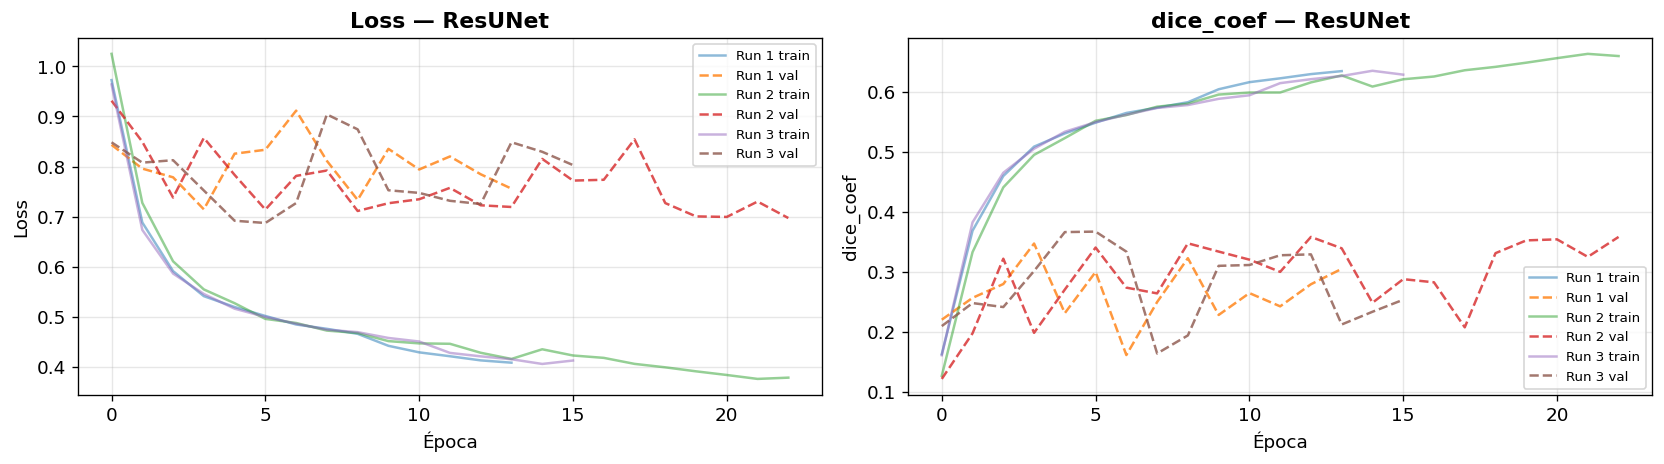


Resumen por run:
 run  test_dice  test_iou  test_loss  train_time  n_epochs
   1     0.3038    0.2036     0.7608   2253.4507        14
   2     0.3464    0.2315     0.7275   3745.7072        23
   3     0.2395    0.1551     0.8249   2605.7758        16

═══ Comparación de los 3 modelos entrenados ═══
Modelo               Dice                   IoU                    Tiempo      
────────────────────────────────────────────────────────────────────────────────
UNet                 0.3180 ± 0.0202     0.2480 ± 0.0048     51.0 min
AttentionUNet        0.3192 ± 0.0259     0.2263 ± 0.0240     47.3 min
ResUNet              0.2966 ± 0.0538     0.1967 ± 0.0387     47.8 min


In [24]:
# ─── Curvas y comparación con modelos anteriores ─────────────────────
plot_training_curves(results_resunet, metric='dice_coef')

print('\nResumen por run:')
print(pd.DataFrame(results_resunet['runs']).round(4).to_string(index=False))

print(f'\n═══ Comparación de los 3 modelos entrenados ═══')
print(f'{"Modelo":<20s} {"Dice":<22s} {"IoU":<22s} {"Tiempo":<12s}')
print('─' * 80)
for name in ['UNet', 'AttentionUNet', 'ResUNet']:
    r = all_results[name]
    print(f'{name:<20s} '
          f'{r["dice_mean"]:.4f} ± {r["dice_std"]:.4f}     '
          f'{r["iou_mean"]:.4f} ± {r["iou_std"]:.4f}     '
          f'{r["time_mean"]/60:.1f} min')

In [25]:
# ═════════════════════════════════════════════════════════════════════
# MODELO 4 — DUAL-HEAD U-NET (Segmentación + Clasificación)
# ─────────────────────────────────────────────────────────────────────
# Referencia: Van Boxtel et al. (2021) — arXiv:2106.00373
#   Concepto: Clasificador CNN explícito (¿hay BP en esta imagen?) +
#   segmentador U-Net. En inference, si P(nervio) < 0.5, máscara = 0.
#
# Ataca directamente el problema principal del dataset:
#   - 60% imágenes sin nervio → falsos positivos destruyen el Dice
#   - La rama clasificadora "filtra" antes de segmentar
#
# Arquitectura: U-Net estándar + rama CNN desde el bottleneck
# ═════════════════════════════════════════════════════════════════════

def build_dual_head_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
                         base_filters=32, depth=4, dropout_rate=0.2):
    """
    Dual-head U-Net:
        - Output 1: máscara de segmentación (H, W, 1) con sigmoid
        - Output 2: probabilidad de presencia de nervio (1,) con sigmoid
    """
    inputs = layers.Input(shape=input_shape, name='input')

    # ─── ENCODER ─────────────────────────────────────────────────────
    skip_connections = []
    x = inputs
    for level in range(depth):
        filters = base_filters * (2 ** level)
        x = conv_block_v2(x, filters, name=f'enc{level+1}')
        skip_connections.append(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f'pool{level+1}')(x)

    # ─── BOTTLENECK ──────────────────────────────────────────────────
    bottleneck_filters = base_filters * (2 ** depth)
    bottleneck = conv_block_v2(x, bottleneck_filters,
                                dropout_rate=dropout_rate, name='bottleneck')

    # ─── RAMA 2: CLASIFICADOR (desde bottleneck) ─────────────────────
    cls = layers.GlobalAveragePooling2D(name='cls_gap')(bottleneck)
    cls = layers.Dense(128, activation='relu',
                       kernel_initializer='he_normal', name='cls_dense1')(cls)
    cls = layers.Dropout(0.3, name='cls_drop1')(cls)
    cls = layers.Dense(64, activation='relu',
                       kernel_initializer='he_normal', name='cls_dense2')(cls)
    cls = layers.Dropout(0.3, name='cls_drop2')(cls)
    cls_output = layers.Dense(1, activation='sigmoid',
                               dtype='float32', name='cls_output')(cls)

    # ─── DECODER (rama de segmentación) ──────────────────────────────
    x = bottleneck
    for level in reversed(range(depth)):
        filters = base_filters * (2 ** level)
        x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2,
                                    padding='same', name=f'up{level+1}')(x)
        x = layers.Concatenate(name=f'concat{level+1}')([x, skip_connections[level]])
        x = conv_block_v2(x, filters, dropout_rate=dropout_rate, name=f'dec{level+1}')

    seg_output = layers.Conv2D(1, kernel_size=1, activation='sigmoid',
                                dtype='float32', name='seg_output')(x)

    model = models.Model(inputs=inputs, outputs=[seg_output, cls_output],
                         name='Dual-Head-U-Net')
    return model


# ─── Pipeline especial para dual-head: (img) → (mask, cls_label) ─────
def tf_load_dual_head(img_path, mask_path):
    """Wrapper que retorna (img, (mask, cls_label)) para dual-head."""
    img, mask = tf.numpy_function(
        load_image_mask,
        inp=[img_path, mask_path],
        Tout=[tf.float32, tf.float32]
    )
    img.set_shape((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    mask.set_shape((IMG_HEIGHT, IMG_WIDTH, 1))

    # Label de clasificación: 1 si la máscara tiene píxeles positivos
    cls_label = tf.cast(tf.reduce_sum(mask) > 0, tf.float32)
    cls_label = tf.reshape(cls_label, (1,))

    return img, (mask, cls_label)


def augment_dual_head(img, targets):
    """Augmentation para dual-head: solo voltea/transforma imagen y máscara."""
    mask, cls_label = targets

    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.8:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
    img  = tf.image.rot90(img,  k=k)
    mask = tf.image.rot90(mask, k=k)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.random_brightness(img, max_delta=0.2)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    if tf.random.uniform(()) > 0.5:
        noise = tf.random.normal(tf.shape(img), mean=0.0, stddev=0.03)
        img = img + noise

    return img, (mask, cls_label)


def build_dataset_dual_head(dataframe, batch_size=BATCH_SIZE, training=False, shuffle=False):
    """Construye dataset especial para dual-head."""
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe['img_path'].values,
        dataframe['mask_path'].values
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(dataframe), 1000),
                        seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(tf_load_dual_head, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(augment_dual_head, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# ─── Verificación ────────────────────────────────────────────────────
model_test = build_dual_head_unet()
print('═' * 60)
print('ARQUITECTURA DUAL-HEAD U-NET')
print('═' * 60)
print(f'Input shape       : {model_test.input_shape}')
print(f'Output seg shape  : {model_test.output_shape[0]}')
print(f'Output cls shape  : {model_test.output_shape[1]}')
print(f'Parámetros totales: {model_test.count_params():,}')
print(f'\nRama 1 (segmentación): U-Net encoder-decoder con skip connections')
print(f'Rama 2 (clasificación): GAP + Dense[128→64→1] con dropout 0.3')
print(f'Post-inference: si P(nervio) < 0.5, la máscara se zerea')

del model_test
K.clear_session()
gc.collect()
print('\n Arquitectura Dual-head U-Net definida')

════════════════════════════════════════════════════════════
ARQUITECTURA DUAL-HEAD U-NET
════════════════════════════════════════════════════════════
Input shape       : (None, 256, 256, 1)
Output seg shape  : (None, 256, 256, 1)
Output cls shape  : (None, 1)
Parámetros totales: 7,845,282

Rama 1 (segmentación): U-Net encoder-decoder con skip connections
Rama 2 (clasificación): GAP + Dense[128→64→1] con dropout 0.3
Post-inference: si P(nervio) < 0.5, la máscara se zerea

 Arquitectura Dual-head U-Net definida


In [26]:
# ═════════════════════════════════════════════════════════════════════
# ENTRENAMIENTO — MODELO 4: DUAL-HEAD U-NET
# Función de pérdida especial: seg_loss + α·cls_loss
# Post-procesamiento obligatorio en inference
# ═════════════════════════════════════════════════════════════════════

def train_dual_head(train_df, val_df, test_df,
                    n_runs=N_RUNS_REMAINING, epochs=EPOCHS,
                    batch_size=BATCH_SIZE, lr=LR):
    """Entrena Dual-head U-Net con post-procesamiento y reporta dos scores."""
    print('═' * 65)
    print(f'ENTRENANDO: DualHeadUNet   ({n_runs} runs — pipeline especial)')
    print('═' * 65)

    val_ds  = build_dataset_dual_head(val_df,  batch_size=batch_size, training=False, shuffle=False)
    test_ds = build_dataset_dual_head(test_df, batch_size=batch_size, training=False, shuffle=False)

    runs_results = []
    histories    = []
    n_params     = None

    for run_idx in range(n_runs):
        print(f'\n── Run {run_idx + 1}/{n_runs} ' + '─' * 50)

        run_seed = SEED + run_idx
        tf.random.set_seed(run_seed)
        np.random.seed(run_seed)
        random.seed(run_seed)

        train_ds = build_dataset_dual_head(train_df, batch_size=batch_size,
                                            training=True, shuffle=True)

        model = build_dual_head_unet()
        model.compile(
            optimizer=optimizers.Adam(learning_rate=lr),
            loss={
                'seg_output': bce_dice_loss,
                'cls_output': keras.losses.binary_crossentropy
            },
            loss_weights={
                'seg_output': 1.0,   # peso para segmentación
                'cls_output': 0.3    # peso para clasificación (secundaria)
            },
            metrics={
                'seg_output': [dice_coef, iou_metric],
                'cls_output': ['accuracy']
            }
        )

        if n_params is None:
            n_params = model.count_params()
            print(f'   Parámetros del modelo: {n_params:,}')

        ckpt_path = WEIGHTS_DIR / f'DualHeadUNet_run{run_idx+1}.weights.h5'
        cbs = [
            callbacks.ModelCheckpoint(
                filepath=str(ckpt_path),
                monitor='val_seg_output_dice_coef',
                mode='max', save_best_only=True, save_weights_only=True, verbose=0
            ),
            callbacks.EarlyStopping(
                monitor='val_seg_output_dice_coef',
                mode='max', patience=10, restore_best_weights=True, verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_seg_output_dice_coef',
                mode='max', factor=0.5, patience=5, min_lr=1e-7, verbose=0
            )
        ]

        t0 = time.time()
        history = model.fit(train_ds, epochs=epochs, validation_data=val_ds,
                             callbacks=cbs, verbose=2)
        train_time = time.time() - t0

        # ─── Evaluación con POST-PROCESAMIENTO ───────────────────────
        print('   Calculando Dice raw y Dice con post-procesamiento...')

        dice_raw_vals = []
        dice_pp_vals  = []
        iou_raw_vals  = []
        iou_pp_vals   = []
        cls_acc_vals  = []

        for imgs_batch, (masks_batch, cls_batch) in test_ds:
            seg_pred, cls_pred = model.predict(imgs_batch, verbose=0)

            masks_np = masks_batch.numpy()
            cls_np   = cls_batch.numpy().flatten()
            cls_pred_np = cls_pred.flatten()

            # Dice por imagen (SIN post-procesamiento)
            for i in range(seg_pred.shape[0]):
                y_true = masks_np[i].flatten()
                y_pred = seg_pred[i].flatten()
                inter  = (y_true * y_pred).sum()
                dice   = (2 * inter + 1.0) / (y_true.sum() + y_pred.sum() + 1.0)
                dice_raw_vals.append(dice)

                y_pred_bin = (y_pred > 0.5).astype(np.float32)
                inter_b = (y_true * y_pred_bin).sum()
                union_b = y_true.sum() + y_pred_bin.sum() - inter_b
                iou = (inter_b + 1.0) / (union_b + 1.0)
                iou_raw_vals.append(iou)

                # CON post-procesamiento: si P(nervio) < 0.5, máscara = 0
                if cls_pred_np[i] < 0.5:
                    y_pred_pp = np.zeros_like(y_pred)
                else:
                    y_pred_pp = y_pred

                inter_pp = (y_true * y_pred_pp).sum()
                dice_pp  = (2 * inter_pp + 1.0) / (y_true.sum() + y_pred_pp.sum() + 1.0)
                dice_pp_vals.append(dice_pp)

                y_pred_pp_bin = (y_pred_pp > 0.5).astype(np.float32)
                inter_pp_b = (y_true * y_pred_pp_bin).sum()
                union_pp_b = y_true.sum() + y_pred_pp_bin.sum() - inter_pp_b
                iou_pp = (inter_pp_b + 1.0) / (union_pp_b + 1.0)
                iou_pp_vals.append(iou_pp)

            # Accuracy del clasificador
            cls_pred_bin = (cls_pred_np > 0.5).astype(np.float32)
            acc = (cls_pred_bin == cls_np).mean()
            cls_acc_vals.append(acc)

        dice_raw = float(np.mean(dice_raw_vals))
        dice_pp  = float(np.mean(dice_pp_vals))
        iou_raw  = float(np.mean(iou_raw_vals))
        iou_pp   = float(np.mean(iou_pp_vals))
        cls_acc  = float(np.mean(cls_acc_vals))

        runs_results.append({
            'run'           : run_idx + 1,
            'test_dice_raw' : dice_raw,
            'test_dice_pp'  : dice_pp,
            'test_iou_raw'  : iou_raw,
            'test_iou_pp'   : iou_pp,
            'cls_accuracy'  : cls_acc,
            'test_dice'     : dice_pp,   # usamos PP como score oficial
            'test_iou'      : iou_pp,
            'train_time'    : train_time,
            'n_epochs'      : len(history.history['loss'])
        })
        histories.append(history.history)

        print(f'   → Dice raw   : {dice_raw:.4f}  |  IoU raw   : {iou_raw:.4f}')
        print(f'   → Dice PP    : {dice_pp:.4f}  |  IoU PP    : {iou_pp:.4f}')
        print(f'   → Cls accuracy: {cls_acc:.4f}  |  Tiempo: {train_time/60:.1f} min')

        del model
        K.clear_session()
        gc.collect()

    runs_df = pd.DataFrame(runs_results)
    summary = {
        'model'        : 'DualHeadUNet',
        'runs'         : runs_results,
        'histories'    : histories,
        'n_params'     : n_params,
        'dice_mean'    : float(runs_df['test_dice'].mean()),
        'dice_std'     : float(runs_df['test_dice'].std()) if len(runs_df) > 1 else 0.0,
        'iou_mean'     : float(runs_df['test_iou'].mean()),
        'iou_std'      : float(runs_df['test_iou'].std()) if len(runs_df) > 1 else 0.0,
        'dice_raw_mean': float(runs_df['test_dice_raw'].mean()),
        'dice_pp_mean' : float(runs_df['test_dice_pp'].mean()),
        'cls_acc_mean' : float(runs_df['cls_accuracy'].mean()),
        'time_mean'    : float(runs_df['train_time'].mean()),
        'time_std'     : float(runs_df['train_time'].std()) if len(runs_df) > 1 else 0.0,
    }

    print('\n' + '═' * 65)
    print(f'RESULTADOS FINALES — DualHeadUNet')
    print('═' * 65)
    print(f'Dice (test, raw)            : {summary["dice_raw_mean"]:.4f}')
    print(f'Dice (test, POST-PROC oficial): {summary["dice_mean"]:.4f} ± {summary["dice_std"]:.4f}')
    print(f'IoU  (test, POST-PROC)      : {summary["iou_mean"]:.4f} ± {summary["iou_std"]:.4f}')
    print(f'Cls accuracy                : {summary["cls_acc_mean"]:.4f}')
    print(f'Parámetros                  : {summary["n_params"]:,}')
    print(f'Tiempo medio                : {summary["time_mean"]/60:.1f} min por run')
    return summary


# ─── Ejecutar entrenamiento ──────────────────────────────────────────
results_dualhead = train_dual_head(train_df, val_df, test_df,
                                    n_runs=N_RUNS_REMAINING,
                                    epochs=EPOCHS,
                                    batch_size=BATCH_SIZE,
                                    lr=LR)
all_results['DualHeadUNet'] = results_dualhead

import json
results_to_save = {k: v for k, v in results_dualhead.items() if k != 'histories'}
with open(RESULTS_DIR / 'DualHeadUNet_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print(f'\n Resultados guardados en: {RESULTS_DIR / "DualHeadUNet_results.json"}')

═════════════════════════════════════════════════════════════════
ENTRENANDO: DualHeadUNet   (3 runs — pipeline especial)
═════════════════════════════════════════════════════════════════

── Run 1/3 ──────────────────────────────────────────────────
   Parámetros del modelo: 7,845,282
Epoch 1/50
480/480 - 141s - loss: 1.4495 - seg_output_loss: 1.2457 - cls_output_loss: 0.6794 - seg_output_dice_coef: 0.0270 - seg_output_iou_metric: 0.0032 - cls_output_accuracy: 0.6014 - val_loss: 1.3035 - val_seg_output_loss: 1.1051 - val_cls_output_loss: 0.6612 - val_seg_output_dice_coef: 0.0240 - val_seg_output_iou_metric: 0.0119 - val_cls_output_accuracy: 0.5769 - lr: 1.0000e-04 - 141s/epoch - 293ms/step
Epoch 2/50
480/480 - 137s - loss: 1.2314 - seg_output_loss: 1.0367 - cls_output_loss: 0.6491 - seg_output_dice_coef: 0.1005 - seg_output_iou_metric: 0.1970 - cls_output_accuracy: 0.6168 - val_loss: 1.2011 - val_seg_output_loss: 0.9903 - val_cls_output_loss: 0.7027 - val_seg_output_dice_coef: 0.1093 

In [27]:
all_results['DualHeadUNet'] = results_dualhead

import json
results_to_save = {k: v for k, v in results_dualhead.items() if k != 'histories'}
with open(RESULTS_DIR / 'DualHeadUNet_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print(f'\n Resultados guardados en: {RESULTS_DIR / "DualHeadUNet_results.json"}')


 Resultados guardados en: C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2\ProyectoUltrasound\ultrasound-nerve-segmentation\results\DualHeadUNet_results.json


In [28]:
# ═════════════════════════════════════════════════════════════════════
# MODELO 5 — TU-NET (Transformer + U-Net, SOTA del dataset)
# ─────────────────────────────────────────────────────────────────────
# Referencia: Li et al. (2023) - Frontiers in Physiology
#   Dice reportado en Kaggle: 79.59%
#
# Arquitectura: U-Net + bloque Transformer en el bottleneck
# para capturar dependencias espaciales de largo alcance.
#
# Ajustes para RTX 4050:
#   - Transformer ligero: 2 layers, 4 heads, key_dim=32
#   - Batch size 8 (mayor consumo de memoria)
#   - Dropout 0.2 en todas partes
# ═════════════════════════════════════════════════════════════════════

def transformer_block(x, num_heads=4, key_dim=32, ff_dim=256,
                       dropout=0.1, name=None):
    """Bloque Transformer encoder estándar.
    
    Input:  (batch, seq_len, channels)
    Output: (batch, seq_len, channels)
    """
    # Multi-head self-attention
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=dropout,
        name=f'{name}_mha' if name else None
    )(x, x)
    attn_output = layers.Dropout(dropout, name=f'{name}_drop1' if name else None)(attn_output)
    x1 = layers.LayerNormalization(epsilon=1e-6,
                                    name=f'{name}_ln1' if name else None)(x + attn_output)

    # Feed-forward network
    ff = layers.Dense(ff_dim, activation='gelu',
                      name=f'{name}_ff1' if name else None)(x1)
    ff = layers.Dense(x.shape[-1],
                      name=f'{name}_ff2' if name else None)(ff)
    ff = layers.Dropout(dropout, name=f'{name}_drop2' if name else None)(ff)
    x2 = layers.LayerNormalization(epsilon=1e-6,
                                    name=f'{name}_ln2' if name else None)(x1 + ff)
    return x2


def build_tunet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
                base_filters=32, depth=4, dropout_rate=0.2,
                n_transformer_blocks=2, num_heads=4):
    """
    TU-Net — U-Net con bloques Transformer en el bottleneck.
    
    El bottleneck (16x16 spatial, 512 channels) se aplana a secuencia
    de 256 tokens de 512-dim, pasa por N bloques transformer, y se
    remodela de vuelta a mapa espacial antes del decoder.
    """
    inputs = layers.Input(shape=input_shape, name='input')

    # ─── ENCODER ─────────────────────────────────────────────────────
    skip_connections = []
    x = inputs
    for level in range(depth):
        filters = base_filters * (2 ** level)
        x = conv_block_v2(x, filters, name=f'enc{level+1}')
        skip_connections.append(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f'pool{level+1}')(x)

    # ─── BOTTLENECK CONVOLUCIONAL ────────────────────────────────────
    bottleneck_filters = base_filters * (2 ** depth)
    x = conv_block_v2(x, bottleneck_filters,
                       dropout_rate=dropout_rate, name='bottleneck_conv')

    # ─── BLOQUES TRANSFORMER EN EL BOTTLENECK ────────────────────────
    # Shape actual: (B, 16, 16, 512)
    _, h_b, w_b, c_b = x.shape
    seq_len = h_b * w_b

    # Aplanar a secuencia: (B, 256, 512)
    x = layers.Reshape((seq_len, c_b), name='flatten_to_seq')(x)

    # Positional embedding aprendible
    pos_emb = tf.keras.layers.Embedding(
        input_dim=seq_len, output_dim=c_b, name='pos_emb'
    )(tf.range(start=0, limit=seq_len, delta=1))
    x = layers.Add(name='add_pos_emb')([x, pos_emb])

    # Aplicar N bloques transformer
    for i in range(n_transformer_blocks):
        x = transformer_block(
            x, num_heads=num_heads, key_dim=c_b // num_heads,
            ff_dim=c_b * 2, dropout=dropout_rate, name=f'transformer{i+1}'
        )

    # Remodelar de vuelta a espacial: (B, 16, 16, 512)
    x = layers.Reshape((h_b, w_b, c_b), name='reshape_to_spatial')(x)

    # ─── DECODER ─────────────────────────────────────────────────────
    for level in reversed(range(depth)):
        filters = base_filters * (2 ** level)
        x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2,
                                    padding='same', name=f'up{level+1}')(x)
        x = layers.Concatenate(name=f'concat{level+1}')([x, skip_connections[level]])
        x = conv_block_v2(x, filters, dropout_rate=dropout_rate, name=f'dec{level+1}')

    outputs = layers.Conv2D(1, kernel_size=1, activation='sigmoid',
                             dtype='float32', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='TU-Net')
    return model


# ─── Verificación ────────────────────────────────────────────────────
model_test = build_tunet()
print('═' * 60)
print('ARQUITECTURA TU-NET')
print('═' * 60)
print(f'Input shape   : {model_test.input_shape}')
print(f'Output shape  : {model_test.output_shape}')
print(f'Parámetros    : {model_test.count_params():,}')
print(f'Transformer blocks: 2  |  Heads: 4  |  Key dim: 128')
print(f'Bottleneck secuencial: 16×16 = 256 tokens de 512-dim')

del model_test
K.clear_session()
gc.collect()
print('\n Arquitectura TU-Net definida')

════════════════════════════════════════════════════════════
ARQUITECTURA TU-NET
════════════════════════════════════════════════════════════
Input shape   : (None, 256, 256, 1)
Output shape  : (256, 256, 256, 1)
Parámetros    : 11,976,865
Transformer blocks: 2  |  Heads: 4  |  Key dim: 128
Bottleneck secuencial: 16×16 = 256 tokens de 512-dim

 Arquitectura TU-Net definida


In [29]:
def build_tunet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
                base_filters=32, depth=4, dropout_rate=0.2,
                n_transformer_blocks=2, num_heads=4):
    """
    TU-Net — U-Net con bloques Transformer en el bottleneck.
    (Versión corregida v2 — positional embedding con broadcast explícito)
    """
    inputs = layers.Input(shape=input_shape, name='input')

    # ─── ENCODER ─────────────────────────────────────────────────────
    skip_connections = []
    x = inputs
    for level in range(depth):
        filters = base_filters * (2 ** level)
        x = conv_block_v2(x, filters, name=f'enc{level+1}')
        skip_connections.append(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f'pool{level+1}')(x)

    # ─── BOTTLENECK CONVOLUCIONAL ────────────────────────────────────
    bottleneck_filters = base_filters * (2 ** depth)
    x = conv_block_v2(x, bottleneck_filters, name='bottleneck_conv')
    x = layers.SpatialDropout2D(dropout_rate, name='bottleneck_sdrop')(x)

    # ─── BLOQUES TRANSFORMER EN EL BOTTLENECK ────────────────────────
    _, h_b, w_b, c_b = x.shape
    seq_len = h_b * w_b

    # Aplanar a secuencia: (B, 256, 512)
    x = layers.Reshape((seq_len, c_b), name='flatten_to_seq')(x)

    # ─── Positional embedding con Lambda (broadcast explícito) ───────
    # Creamos los índices 0..seq_len-1, los embeddemos, y sumamos con broadcast
    class PositionalEmbedding(layers.Layer):
        def __init__(self, seq_len, d_model, **kwargs):
            super().__init__(**kwargs)
            self.seq_len = seq_len
            self.d_model = d_model
            self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)

        def call(self, x):
            positions = tf.range(start=0, limit=self.seq_len, delta=1)
            pos_embeddings = self.pos_emb(positions)   # (seq_len, d_model)
            # Expandir a (1, seq_len, d_model) para broadcast con batch
            pos_embeddings = tf.expand_dims(pos_embeddings, axis=0)
            return x + pos_embeddings

    x = PositionalEmbedding(seq_len, c_b, name='pos_emb_layer')(x)

    # Aplicar N bloques transformer
    for i in range(n_transformer_blocks):
        x = transformer_block(
            x, num_heads=num_heads, key_dim=c_b // num_heads,
            ff_dim=c_b * 2, dropout=dropout_rate, name=f'transformer{i+1}'
        )

    # Remodelar de vuelta a espacial: (B, 16, 16, 512)
    x = layers.Reshape((h_b, w_b, c_b), name='reshape_to_spatial')(x)

    # ─── DECODER ─────────────────────────────────────────────────────
    for level in reversed(range(depth)):
        filters = base_filters * (2 ** level)
        x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2,
                                    padding='same', name=f'up{level+1}')(x)
        x = layers.Concatenate(name=f'concat{level+1}')([x, skip_connections[level]])
        x = conv_block_v2(x, filters, dropout_rate=dropout_rate, name=f'dec{level+1}')

    outputs = layers.Conv2D(1, kernel_size=1, activation='sigmoid',
                             dtype='float32', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='TU-Net')
    return model


# ─── Verificación rápida con batch dummy ─────────────────────────────
model_test = build_tunet()
print(f'Parámetros: {model_test.count_params():,}')
print(f'Output shape: {model_test.output_shape}')

# Test de forward pass con training=True (fuerza dropout)
dummy = tf.random.normal((2, 256, 256, 1))
out = model_test(dummy, training=True)
print(f'Forward pass con dropout activo: OK, shape = {out.shape}')

# Test también con training=False (inference)
out_inf = model_test(dummy, training=False)
print(f'Forward pass inference: OK, shape = {out_inf.shape}')

del model_test
K.clear_session()
gc.collect()

Parámetros: 12,107,937
Output shape: (None, 256, 256, 1)
Forward pass con dropout activo: OK, shape = (2, 256, 256, 1)
Forward pass inference: OK, shape = (2, 256, 256, 1)


9286

In [30]:
# ═════════════════════════════════════════════════════════════════════
# ENTRENAMIENTO — MODELO 5: TU-NET
# Batch size 8 (transformer consume más memoria)
# ═════════════════════════════════════════════════════════════════════

BATCH_SIZE_TUNET = 8  # Bajar por el transformer

results_tunet = train_model_v2(
    model_builder = build_tunet,
    model_name    = 'TUNet',
    train_df      = train_df,
    val_df        = val_df,
    test_df       = test_df,
    n_runs        = N_RUNS_REMAINING,
    epochs        = EPOCHS,
    batch_size    = BATCH_SIZE_TUNET,
    lr            = LR,
    loss_fn       = bce_dice_loss
)

all_results['TUNet'] = results_tunet

import json
results_to_save = {k: v for k, v in results_tunet.items() if k != 'histories'}
with open(RESULTS_DIR / 'TUNet_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print(f'\nResultados guardados en: {RESULTS_DIR / "TUNet_results.json"}')
print('\n' + '═' * 65)
print('TODOS LOS MODELOS ENTRENADOS')
print('═' * 65)
for name, r in all_results.items():
    print(f'{name:<20s} Dice: {r["dice_mean"]:.4f} ± {r["dice_std"]:.4f}')

═════════════════════════════════════════════════════════════════
ENTRENANDO: TUNet   (3 runs — pipeline mejorado)
═════════════════════════════════════════════════════════════════

── Run 1/3 ──────────────────────────────────────────────────
   Parámetros del modelo: 12,107,937
Epoch 1/50
480/480 - 154s - loss: 1.0324 - dice_coef: 0.1145 - iou_metric: 0.1886 - val_loss: 1.0947 - val_dice_coef: 0.1408 - val_iou_metric: 0.1287 - lr: 1.0000e-04 - 154s/epoch - 320ms/step
Epoch 2/50
480/480 - 150s - loss: 0.8028 - dice_coef: 0.2734 - iou_metric: 0.3285 - val_loss: 0.8561 - val_dice_coef: 0.2123 - val_iou_metric: 0.2239 - lr: 1.0000e-04 - 150s/epoch - 313ms/step
Epoch 3/50
480/480 - 150s - loss: 0.6706 - dice_coef: 0.3869 - iou_metric: 0.3652 - val_loss: 0.8714 - val_dice_coef: 0.1784 - val_iou_metric: 0.2227 - lr: 1.0000e-04 - 150s/epoch - 313ms/step
Epoch 4/50
480/480 - 149s - loss: 0.5915 - dice_coef: 0.4599 - iou_metric: 0.3869 - val_loss: 0.8505 - val_dice_coef: 0.2025 - val_iou_metri